<a href="https://colab.research.google.com/github/shecodespsy/SheCodesPsy-2026/blob/main/Group_Projects%20/Conflict_Task_Dataset/ConflictTask_GroupProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/shecodespsy/SheCodesPsy-2026.git

Cloning into 'SheCodesPsy-2026'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 180 (delta 94), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (180/180), 1.44 MiB | 9.42 MiB/s, done.
Resolving deltas: 100% (94/94), done.


# **Conflict task dataset**

This group project will help you put into practice the Python skills learned during the workshop. It is designed for students who are interested in experimental psychology and who want to learn how researchers analyse behavioural data.

The dataset is a simplified version of the behavioural data published in the article:

> Avancini, C., Ciria, L. F., Alameda, C., Palenciano, A. F., Canales-Johnson, A., Bekinschtein, T. A., & Sanabria, D. (2024). *High-intensity physiological activation disrupts the neural signatures of conflict processing*. Communications Biology, 7, 1625.

In this document, you will find:

1. a brief description of the experiment,
2. an explanation of the dataset,
3. suggestions for possible research questions,
4. ideas for analysing and presenting your results.

You are encouraged to use these suggestions as a starting point, but you do not need to follow them exactly. Try to think like a real researcher: explore the data, ask questions, make plots, interpret your results, and be ready to explain what you found.

**You can then use a code cell to write and execute your python scripts.**

## The experiment

The original study investigated how high physiological activation affects cognitive control. In simple terms, the researchers wanted to know whether people can still deal with conflicting information when they are physically activated by intense exercise.

Participants completed an auditory version of the **Simon task** while cycling on a stationary bike. Each participant completed the task in two exercise conditions:

- **Low-intensity exercise**, which induced a state of **low physical activation**
- **High-intensity exercise**, which induced a state of **high physical activation**

The important point is that the same participants completed both conditions, so each participant can be compared with themselves across low and high intensity.



## What is the Simon task?

In the Simon task, participants must respond to the meaning of a stimulus while ignoring irrelevant spatial information.

In this experiment, participants heard the Spanish words for **left** and **right**:

- "izquierda" = left
- "derecha" = right

The word was presented either to the left ear or to the right ear. Participants had to respond according to the **meaning of the word**, not according to the ear in which they heard it.

For example:

| Word heard | Ear | Correct response | Trial type |
|---|---|---|---|
| "izquierda" | left ear | left response | congruent |
| "derecha" | right ear | right response | congruent |
| "izquierda" | right ear | left response | incongruent |
| "derecha" | left ear | right response | incongruent |

A trial is called **congruent** when the meaning of the word and the side of presentation match.

A trial is called **incongruent** when the meaning of the word and the side of presentation do not match.

Incongruent trials are usually more difficult because the irrelevant spatial information creates conflict. For this reason, participants often respond more slowly and make more errors on incongruent trials than on congruent trials.

<figure>
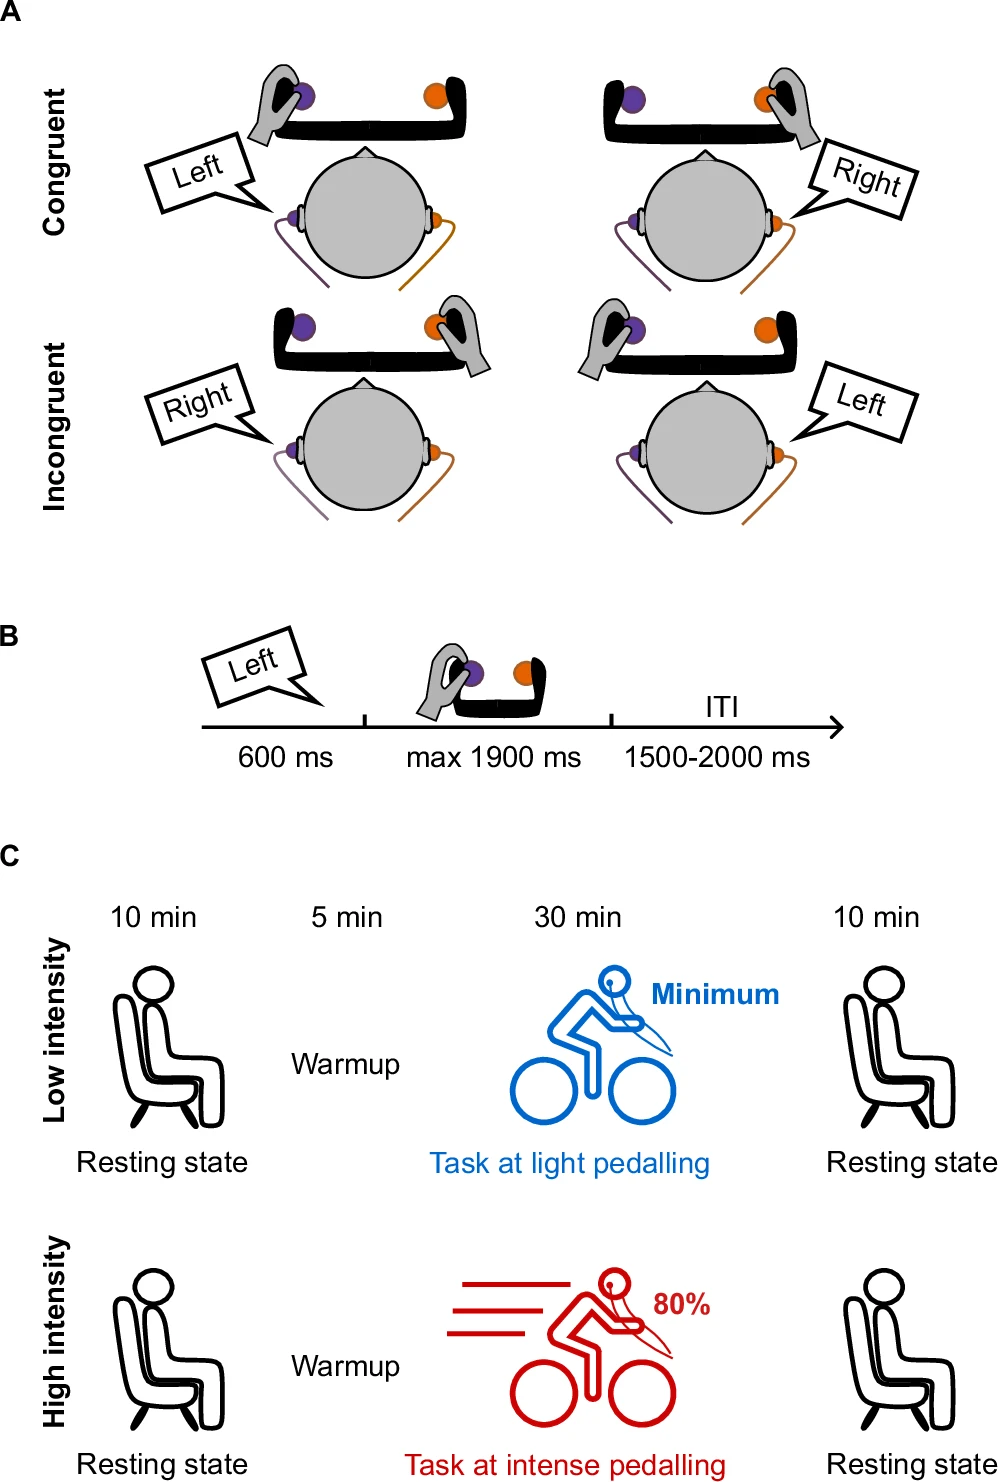
<figcaption>Schematic representation of the auditory Simon task and exercises conditions (taken from the original article).</figcaption>
</figure>


## Key psychological concepts

**<font color = "red"> Cognitive control </font>**

**Cognitive control** is the ability to focus on relevant information and ignore distracting information. In this task, participants need cognitive control because they must focus on the word meaning and ignore the ear in which the word was presented.

\
**<font color = "red"> Conflict effect </font>**

The **conflict effect** measures how much harder incongruent trials are compared with congruent trials.

For reaction times, the conflict effect can be calculated as:

```text
conflict effect = mean RT in incongruent trials - mean RT in congruent trials
```

A positive conflict effect means that participants were slower on incongruent trials than on congruent trials.

For accuracy, the conflict effect can be calculated as:

```text
conflict effect = mean accuracy in congruent trials - mean accuracy in incongruent trials
```

A positive accuracy conflict effect means that participants were more accurate on congruent trials than on incongruent trials.





## The dataset

The dataset you will analyse is a simplified behavioural dataset. It focuses on task performance and does not include the full EEG analysis from the original study.

In the project folder, you will find one datafile (in CSV format) for each of the 25 participants we have selected for this collaborative project. For example:

```text
Group_Projects/
└──/Conflict_Task_Dataset/
    └── sub-01_conflict_behavioural_data.csv
        sub-02_conflict_behavioural_data.csv
        sub-03_conflict_behavioural_data.csv
        ...
```

Each file is organized in columns containing the following variables:

| Column | Meaning |
|---|---|
| `sub_ID` | Participant identifier |
| `trial_number` | Trial number within the session |
| `physical_activation` | Exercise condition, for example `low_activation` or `high_activation` |
| `trial_congruency` | Whether the trial was `congruent` or `incongruent` |
| `response_correctness` | Whether the response for that trial was `correct`or `incorrect`|
| `reaction_times` | Reaction time in milliseconds |


Note that if the participant did not respond to a trial (omission), the columns `response_correctness` and `reaction_times` have the value NaN for that particular trial.

## Suggested initial steps

1. Import the libraries you need
2. Load one datafile to get a feel of how the data is structured and how the imported dataframe looks like
3. Inspect the dataframe (e.g. look at the first rows, check the size of the loaded dataframe, check column names, check the type of information stored in each column, get a quick summary of the numerical varibles)

## Suggested overall structure of your workflow

In this dataset, we have data from 25 participants. For each participant, we may want to apply the same analysis steps: load their data, clean the trials, calculate mean reaction times, calculate accuracy, and store the results.

A common beginner mistake would be to copy and paste the same code 25 times, changing only the participant number each time. This is not a good strategy. It makes the code long, repetitive, and difficult to fix if you make a mistake. Instead, we can ask Python to repeat the same steps for us by using a `for` loop.

A `for` loop allows us to say: “For each participant in the dataset, apply the same cleaning and analysis steps.”

For example, Python can first analyse sub-01, then sub-02, then sub-03, and continue until the last participant.
\
The general idea is:

```python

all_participants = [] # Create an empty list where you can store each individual preprocessed data

for participant in participants:
    # Select the data for one participant
    participant_data = pd.read_csv(file)      # Store the loaded data
    
    # Now do whatever you want to do with the current dataset and later sore it in all_participants

```

**To see how properly load several CSV files using loops, please refer to the documentation in the intro_to_python notebook.**

## Suggested data cleaning

Researchers usually remove trials that cannot be interpreted clearly.

For example, you may decide to remove:

- incorrect responses when analysing reaction times
- missing responses
- reaction times faster than 200 ms

Important: Once you start writing your analysis script comment your code as much as you can!

## Possible research questions

Here are some research questions you could investigate.

<font color = "orange"> Question 1: Do participants show a conflict effect? </font>

Are participants slower or less accurate in incongruent trials than in congruent trials?

This is the most basic question and should usually be your first analysis.

<font color = "teal"> Question 2: Does exercise intensity change overall reaction times and accuracy? </font>

Are participants slower or less accurate during high-intensity exercise compared to low-intensity exercise?

<font color = "purple"> Question 3 (Hard!): Does exercise intensity change the conflict effect? </font>

Is the difference between incongruent and congruent trials larger during high-intensity exercise than during low-intensity exercise?

You can investigate this question using reaction times, accuracy, or both.

This question is directly related to the original study. To answer it, you need to calculate the mean performance for each participant in each combination of conditions:

- low activation, congruent trials
- low activation, incongruent trials
- high activation, congruent trials
- high activation, incongruent trials

In other words, you need to consider two factors:

1. `physical_activation`: low activation vs high activation
2. `trial_congruency`: congruent vs incongruent

Because the same participants completed all conditions, this analysis requires a **two-way repeated-measures ANOVA**. This is more advanced than the statistical tests we have covered in the workshop, so do not worry if it feels challenging.

If you choose this question, your goal is not only to get the final result, but also to practise an important research skill: learning how to look up new methods, understand examples, adapt code, and apply it to your own dataset.

The most important result will be the interaction between `physical_activation` and `trial_congruency`. This interaction tells us whether the conflict effect changes depending on exercise intensity.


---
<font color = "red">**IMPORTANT: You do not have to answer all of the questions.** </font> Choose one question to start with and focus on answering it clearly. Once you have completed that analysis, you can decide whether you have enough time to explore another question.

You are also welcome to develop your own research question. If a different question comes to mind while you are exploring the dataset, you can investigate that instead of using one of the suggested questions.


## Statistics

To answer your research question, you can start by looking at **descriptive statistics**, such as means, standard deviations, and plots. These will help you understand the general pattern in the data.

If you want to go one step further, you can also run some simple **statistical tests**.

For example, you could:

- compare the participant-level conflict effect using a **paired-samples t-test**;
- test whether reaction times depend on both congruency and exercise intensity using an **ANOVA**.

Before running statistical tests, it is important to prepare the data in the correct format. Usually, this means calculating the relevant mean values **separately for each participant** and storing them in a new summary dataframe.

For example, if you want to test whether participants show a conflict effect in reaction times, you would need to repeat the following steps for each participant:

1. Clean the participant’s data.
2. Select the correct trials only.
3. Calculate the mean reaction time for congruent trials.
4. Calculate the mean reaction time for incongruent trials.
5. Store these values in a new dataframe.

At the end of the `for` loop, your new dataframe should contain one row per participant, with columns containing the values you want to compare.

For example:

| participant | mean_rt_congruent | mean_rt_incongruent |
|---|---|---|
| sub-01 | 512 | 548 |
| sub-02 | 489 | 530 |
| sub-03 | 501 | 515 |


## Plot the data

It is important to visualize the data, especially for presenting the results. It can be a simple bar plot comparing the group mean RT of congruent vs incongruent trials.

## Tips for working as a group

- Start simple.
- Make sure everyone understands the dataset before writing code.
- Write comments in your code.
- Save your plots and with clear filenames.
- Keep track of what each variable means.
- You can take snapshots of your output (for example of the stats results) and save it as image or in a power point.


## Useful Python reminders

Select rows

```python
low_df = df[df["intensity"] == "low"]
```

Select columns

```python
df[["participant", "intensity", "congruency", "rt", "accuracy"]]
```

Group and summarise

```python
df.groupby("congruency")["rt"].mean()
```

Group by two variables

```python
df.groupby(["intensity", "congruency"])["rt"].mean()
```

Create a new column

```python
df["is_fast"] = df["rt"] < 500
```

Count values

```python
df["congruency"].value_counts()
```

Use loops to load all participants' files in a list

```python

# Create an empty list
all_data = []

participants_ids = ["sub-01", "sub-02", "sub-03"] # Note that there are more efficient ways in python to define automatically the filenames. For now, let's stick to this simple method.

# Load each participant file
for p_id in participants_ids:
    filename = p_id + "_rest_of_filename.csv"
    df = pd.read_csv(filename)

    # Store the full dataframe in the list
    all_data.append(df)

# Combine all participants into one big dataframe (this depents on your workflow)
data = pd.concat(all_data, ignore_index=True)

```

Use loops to load all participants' files in a dictionary

```python

# Create an empty dictionary
all_data = {}

participants_ids = ["sub-01", "sub-02", "sub-03"] # Note that there are more efficient ways in python to define automatically the filenames. For now, let's stick to this simple method.

# Load each participant file
for p_id in participants_ids:
    filename = p_id + "_rest_of_filename.csv"
    df = pd.read_csv(filename)

    # Store the full dataframe in the list
    all_data[p_id] = df

# Combine all participants into one big dataframe (this depents on your workflow)
data = pd.concat(all_data.values(), ignore_index=True)

```

## A final note

The goal is not to get the "correct" answer. The goal is to practise how psychologists use data:

1. understand the experiment
2. inspect the dataset
3. clean the data carefully
4. calculate meaningful summaries
5. create clear plots

If you manage to answer all research questions: that is amazing! 🙌\
If you manage to answer only one research question: that is amazing! 🙌\
If you don't manage to answer any of the questions but you have made the best out of this group project to consolidate what you have learned during the workshop: that is amazing! 🙌

**The point is: do not stress. Enjoy playing around with Python and with the data!**



In [ ]:
# You can use this cell to write your Python script. You can also create several cells, if that works better for you.